Didn't you read the README file? I said to not look at this. It's just a notebook to test stuff and I'm sure it's full of errors and warnings, go out until you can. I don't want to break the harmonious order of the directory with this file.

In [4]:
import warnings
import pandas as pd
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from photutils.aperture import CircularAperture, aperture_photometry, CircularAnnulus
import pandas as pd
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS, FITSFixedWarning
from photutils.aperture import CircularAperture, aperture_photometry, CircularAnnulus, ApertureStats

/home/gigi/miniconda3/envs/astro/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


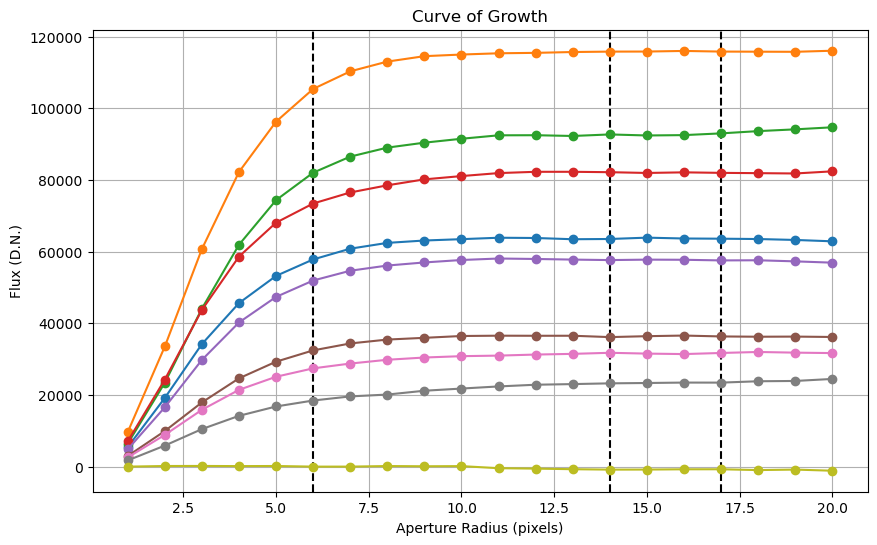

In [13]:
from Photometry_Tool import PhotometryTool
import pandas as pd

positions = pd.read_csv('data/Ra_Deg_comp_stars.txt', names=['Ra', 'Deg'])

path = 'data/2024-11-15_18-15-32_G_-20.00_80.00s_0000_cal.fits'

test = PhotometryTool(path = path, r_star = 6, r_gap = 14, r_sky = 17)

# Reshape the selected row to be a 2D array with shape (1, 2)
# positions = positions.iloc[1].values.reshape(1, 2)

test.plot_curve_of_growth(positions, max_radius = 20)

In [16]:
from utilities import Get_files_names, Load_dataset
import pandas as pd

files_green_filter, files_blue_filter = Get_files_names()
green_dataset, blue_dataset = Load_dataset(files_green_filter, files_blue_filter, 
                             green = True, blue = True)

instr_magnit_1_green = [df['instrumental_magnitude'][1] for df in green_dataset]
instr_magnit_2_green = [df['instrumental_magnitude'][2] for df in green_dataset]

df = pd.DataFrame({'star 1': instr_magnit_1_green, 'star 2': instr_magnit_2_green})

Green Filter Loading:


100%|██████████| 50/50 [05:06<00:00,  6.12s/it]


Blue Filter Loading:


100%|██████████| 48/48 [05:18<00:00,  6.63s/it]


In [3]:
df.cov()

,star 1,star 2
star 1,0.000928,0.000704
star 2,0.000704,0.000737


In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np

julian = [df['AVG Julian Date'][1] for df in blue_dataset]
instr_magnit_1 = [df['instrumental_magnitude'][1] for df in blue_dataset]
instr_magnit_2 = [df['instrumental_magnitude'][2] for df in blue_dataset]
diff_magnit_2_1 = [b - a for a, b in zip(instr_magnit_1, instr_magnit_2)]

sigma_star_1 = [df['sigma instrumental magnitude'][1] for df in blue_dataset]
sigma_star_2 = [df['sigma instrumental magnitude'][2] for df in blue_dataset]
diff_error= [np.sqrt(sigma1**2 + sigma2**2) for sigma1, sigma2 in zip(sigma_star_1, sigma_star_2)]

# Define the linear function
def linear_func(x, a, b):
    return a * x + b

# Perform weighted linear fit
popt, pcov = curve_fit(linear_func, julian, diff_magnit_2_1, sigma=diff_error)

# Extract the parameters
slope_weighted, intercept_weighted = popt

# Print the results
print(f"Weighted Slope: {slope_weighted}")
print(f"Weighted Intercept: {intercept_weighted}")

# Plot the results
ax.plot(julian, linear_func(np.array(julian), *popt), '--', label='Weighted Fitted line')
ax.legend()
plt.show()

Slope: -0.21210781724246794
Intercept: 521919.1748941191
R-squared: 0.32828523272689847
P-value: 2.0816387509305774e-05
Standard error: 0.04473470042382949
Weighted Slope: -0.2156306273177912
Weighted Intercept: 530587.5080924301


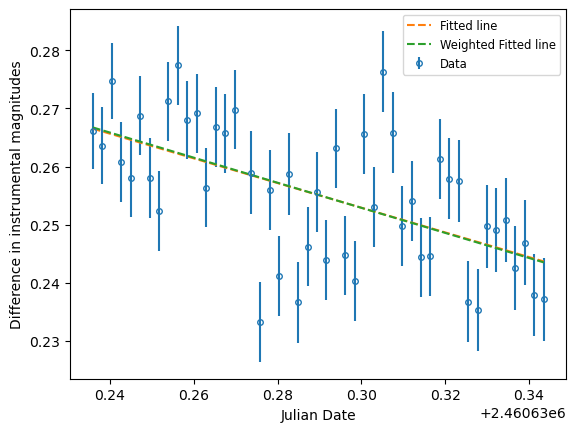

In [ ]:
from scipy.stats import linregress
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np

julian = [df['AVG Julian Date'][1] for df in blue_dataset]
instr_magnit_1 = [df['instrumental_magnitude'][1] for df in blue_dataset]
instr_magnit_2 = [df['instrumental_magnitude'][2] for df in blue_dataset]
diff_magnit_2_1 = [b - a for a, b in zip(instr_magnit_1, instr_magnit_2)]

sigma_star_1 = [df['sigma instrumental magnitude'][1] for df in blue_dataset]
sigma_star_2 = [df['sigma instrumental magnitude'][2] for df in blue_dataset]
diff_error= [np.sqrt(sigma1**2 + sigma2**2) for sigma1, sigma2 in zip(sigma_star_1, sigma_star_2)]


# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(julian, diff_magnit_2_1)

# Print the results
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")
print(f"R-squared: {r_value**2}")
print(f"P-value: {p_value}")
print(f"Standard error: {std_err}")

fig, ax = plt.subplots()
ax.errorbar(julian, diff_magnit_2_1, diff_error, fmt = 'o', markersize=4, fillstyle='none', label = 'Data')
ax.plot(julian, intercept + slope*np.array(julian), '--', label = 'Fitted line')
ax.set(xlabel='Julian Date', ylabel='Difference in instrumental magnitudes')


# Define the linear function
def linear_func(x, a, b):
    return a * x + b

# Perform weighted linear fit
popt, pcov = curve_fit(linear_func, julian, diff_magnit_2_1, sigma=diff_error)

# Extract the parameters
slope_weighted, intercept_weighted = popt

# Print the results
print(f"Weighted Slope: {slope_weighted}")
print(f"Weighted Intercept: {intercept_weighted}")

# Plot the results
ax.plot(julian, linear_func(np.array(julian), *popt), '--', label='Weighted Fitted line')
ax.legend(fontsize = 'small')
plt.show()

In [12]:
path = 'data/2024-11-15_18-15-32_G_-20.00_80.00s_0000_cal.fits'

hdu = fits.open(path)
data = hdu[0].data
header = hdu[0].header

header

SIMPLE  =                    T / C# FITS                                        
BITPIX  =                   16                                                  
NAXIS   =                    2 / Dimensionality                                 
NAXIS1  =                 4008                                                  
NAXIS2  =                 2672                                                  
BZERO   =   32768.000000000000                                                  
EXTEND  =                    T / Extensions are permitted                       
IMAGETYP= 'LIGHT'              / Type of exposure                               
EXPOSURE=                 80.0 / [s] Exposure duration                          
EXPTIME =                 80.0 / [s] Exposure duration                          
DATE-LOC= '2024-11-15T18:15:32.989' / Time of observation (local)               
DATE-OBS= '2024-11-15T17:15:32.989' / Time of observation (UTC)                 
DATE-AVG= '2024-11-15T17:16:

In [13]:
from astropy.time import Time

# Example UTC time
utc_time = header['DATE-AVG']

# Create a Time object
t = Time(utc_time, format='isot', scale='utc')

# Convert to Julian Date
jd = t.jd

jd

2460630.2196057523

In [8]:
from pathlib import Path

files_blue_filter = []
files_green_filter = []

current_directory = Path.cwd()
directory = Path(current_directory / 'data')

# Iterate through all files in the directory
for file_path in directory.iterdir():
    if file_path.is_file():  # Check if it's a file
        if file_path.name.endswith('.fits'):    # Takes only files that ends with .fits
            if 'B' in file_path.name:   # Check if its a blue filtered image
                files_blue_filter.append(file_path.name)
            elif 'G' in file_path.name:     # Check if its a green filtered image
                files_green_filter.append(file_path.name)       

In [10]:
temperatures = []

from tqdm import tqdm   # Just to visualize the loading in the loop for.

for i in tqdm(files_blue_filter):
    hdu = fits.open(Path(current_directory / 'data' / i))
    data = hdu[0].data
    header = hdu[0].header

    temperatures.append(header['CCD-Temp'])

100%|██████████| 48/48 [04:06<00:00,  5.13s/it]


In [11]:
print(temperatures)

[-20.0, -20.0, -20.03125, -20.0, -20.03125, -20.0, -20.03125, -20.03125, -20.03125, -20.0, -20.0, -20.0, -20.03125, -20.03125, -20.03125, -20.0, -20.0, -20.0625, -20.0, -20.0, -20.0, -20.0, -20.03125, -20.0, -20.03125, -20.0, -20.0, -20.03125, -19.96875, -20.0, -20.03125, -20.03125, -20.03125, -20.03125, -20.03125, -20.0, -20.0, -20.0, -20.03125, -20.0, -20.0, -20.0, -20.0, -20.0, -20.0, -20.03125, -20.03125, -20.03125]


In [1]:
import pandas as pd
from Photometry_Tool import PhotometryTool

path = 'data/2024-11-15_18-15-32_G_-20.00_80.00s_0000_cal.fits'

tool = PhotometryTool(path = path, r_star = 6, r_gap = 14, r_sky = 17)

positions = pd.read_csv('data/Ra_Deg_comp_stars.txt', names = ['Ra', 'Dec'])

df_results = tool.analyze(positions)

display(df_results)

/home/gigi/miniconda3/envs/astro/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/c/Users/gigig/Documents/University/labo astro/working_directory/Photometry/Photometry_Tool.py:72: RuntimeWarning: invalid value encountered in log10
  inst_mag = -2.5 * (np.log10(0.77) + np.log10(source - bkg * A_s))


,Ra,Dec,Ra Centroid,Dec Centroid,star_aperture_sum,star_aperture_sum,instrumental_magnitude,sigma instrumental magnitude,AVG Julian Date
0,339.975790,13.437280,339.975765,13.437262,160094.335627,264349.447458,-11.620994,0.008395,2.460630e+06
1,339.980072,13.320056,339.980042,13.320097,207707.431125,264367.816707,-12.273077,0.005124,2.460630e+06
2,340.052917,13.471806,340.052928,13.471861,184007.675391,263795.259315,-12.000864,0.006259,2.460630e+06
3,339.790375,13.319195,339.790429,13.319188,175277.705827,262983.264043,-11.880548,0.006854,2.460630e+06
4,340.042542,13.533667,340.042515,13.533575,154395.708285,264656.338023,-11.504407,0.009214,2.460630e+06
5,339.998505,13.593278,339.998451,13.593275,134652.805510,264296.663108,-10.993109,0.013981,2.460630e+06
6,340.193542,13.436806,340.193495,13.436861,129468.514447,263627.167563,-10.810577,0.016289,2.460630e+06
7,339.899048,13.371472,339.898982,13.371466,120128.108204,262941.126303,-10.379643,0.023536,2.460630e+06
8,340.176910,13.078740,340.082745,13.591594,105503.420653,264770.009225,-8.427029,0.135622,2.460630e+06
